In [4]:
import pandas as pd 

df = pd.read_csv("../data/processed/energia_data_limpio.csv")

print(df.head())
print(df.shape)

   Temperatura  Hora  Dia_Semana  Consumo_Energia
0    28.891805     1           1       401.990602
1    22.244071     2           2       334.846911
2    20.909006     3           3       326.926080
3    24.983128     4           4       383.016951
4    24.149077     5           5       388.748151
(10000, 4)


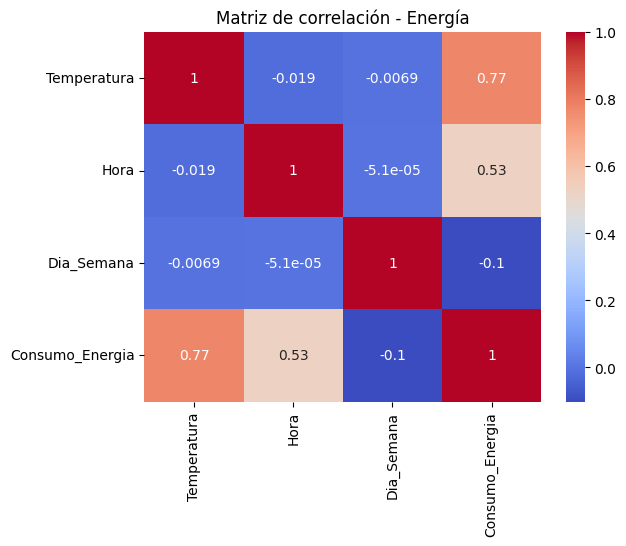

In [5]:
import seaborn as sns 
import matplotlib.pyplot as plt 

sns.heatmap(df.corr(),annot=True,cmap="coolwarm")
plt.title("Matriz de correlación - Energía")
plt.show()

In [6]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression

X = df[["Temperatura","Hora","Dia_Semana"]]
y = df["Consumo_Energia"]

X_train,X_test,y_train,y_test = train_test_split(
    X,y,test_size=0.2,random_state=42
)

model_energia = LinearRegression()
model_energia.fit(X_train,y_train)

y_pred = model_energia.predict(X_test)

In [8]:
import numpy as np 
from sklearn.metrics import mean_squared_error, r2_score

rmse = np.sqrt(mean_squared_error(y_test,y_pred))
r2 = r2_score(y_test,y_pred)

print("RMSE:",rmse)
print("R2:",r2)
print("R2 (%):",r2*100)

RMSE: 20.724832731782318
R2: 0.8968196536749335
R2 (%): 89.68196536749335


In [10]:
coef = pd.DataFrame(
    model_energia.coef_,
    X.columns,
    columns=["Impacto"]
)

print(coef.sort_values(by="Impacto",ascending=False))

              Impacto
Temperatura  9.952866
Hora         5.019813
Dia_Semana  -3.031177


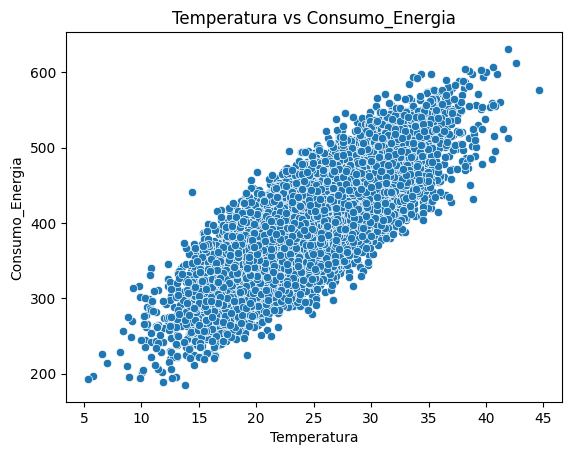

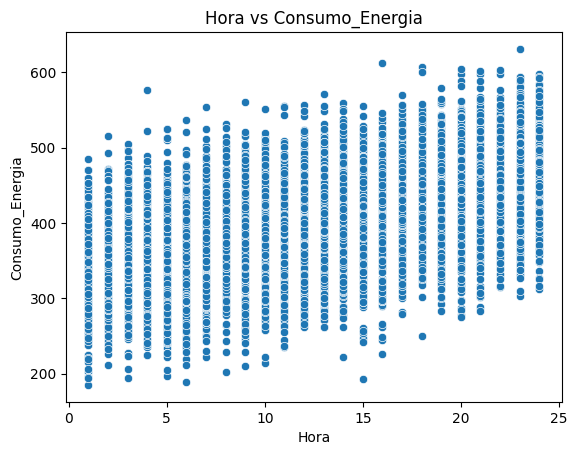

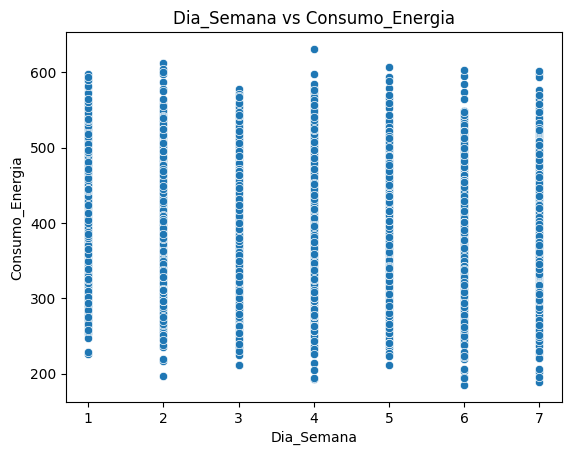

In [11]:
for col in X.columns:
    sns.scatterplot(x=df[col],y=df["Consumo_Energia"])
    plt.title(f"{col} vs Consumo_Energia")
    plt.show()

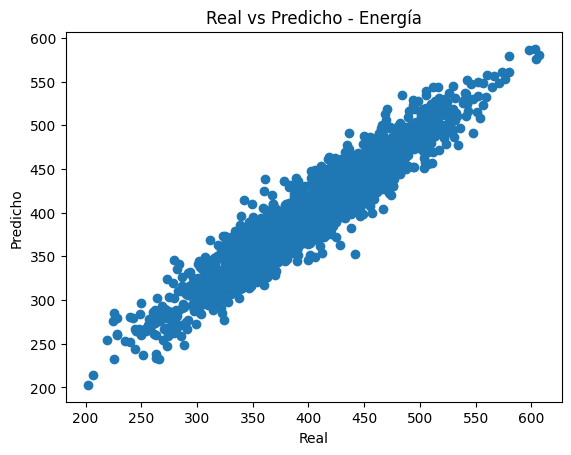

In [12]:
plt.scatter(y_test,y_pred)
plt.xlabel("Real")
plt.ylabel("Predicho")
plt.title("Real vs Predicho - Energía")
plt.show()